In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
import os

os.makedirs("output", exist_ok=True)

In [3]:
image = cv2.imread("butterfly.jpg")

if image is None:
    print("Error: Image not found!")
else:
    print("Image loaded successfully")
    print("Image shape:", image.shape)

Image loaded successfully
Image shape: (414, 738, 3)


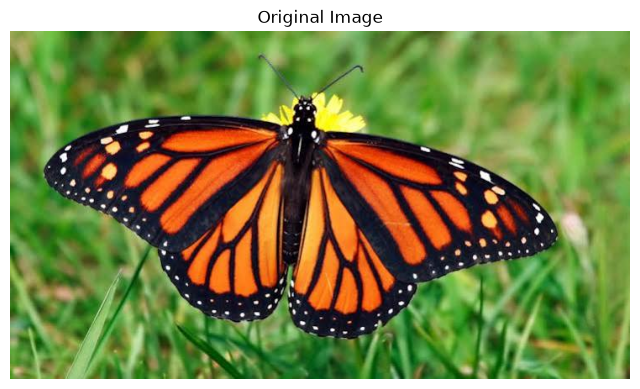

In [4]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [5]:
cv2.imwrite("output/01_original.jpg", image)

True

In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

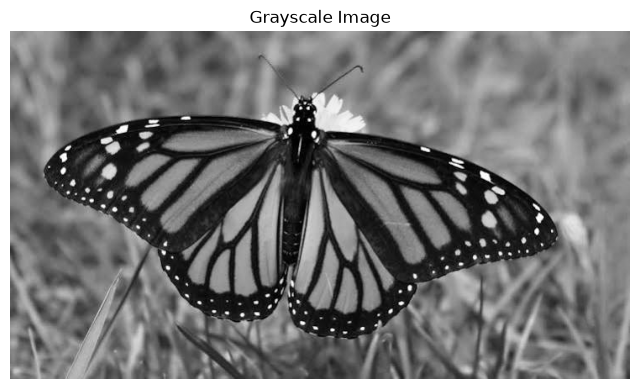

In [7]:
plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [8]:
cv2.imwrite("output/02_grayscale.jpg", gray)

True

In [9]:
blur = cv2.GaussianBlur(gray, (5, 5), 0)

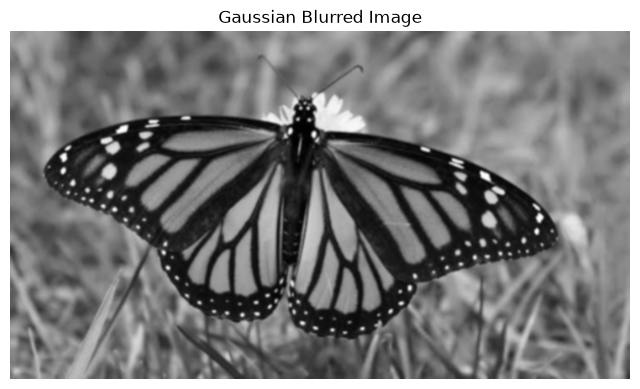

In [10]:
plt.figure(figsize=(8, 6))
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")
plt.show()

In [11]:
cv2.imwrite("output/03_gaussian_blur.jpg", blur)

True

In [12]:
threshold_value = 127

ret, global_threshold = cv2.threshold(
    blur,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

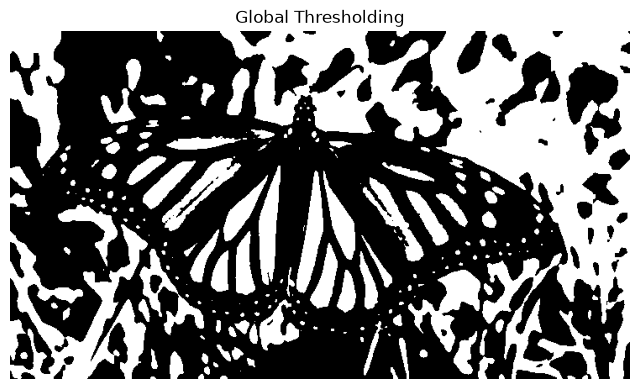

In [13]:
plt.figure(figsize=(8, 6))
plt.imshow(global_threshold, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")
plt.show()

In [14]:
cv2.imwrite(
    "output/04_global_threshold.jpg",
    global_threshold
)

True

In [15]:
otsu_value, otsu_threshold = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

In [16]:
print("Otsu Threshold Value:", otsu_value)

Otsu Threshold Value: 89.0


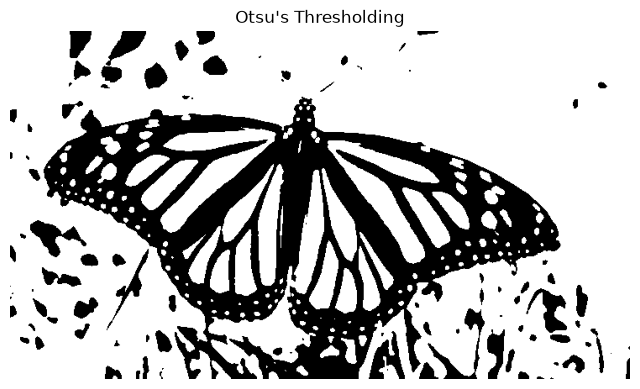

In [17]:
plt.figure(figsize=(8, 6))
plt.imshow(otsu_threshold, cmap="gray")
plt.title("Otsu's Thresholding")
plt.axis("off")
plt.show()

In [18]:
cv2.imwrite(
    "output/05_otsu_threshold.jpg",
    otsu_threshold
)

True

In [19]:
adaptive_threshold = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

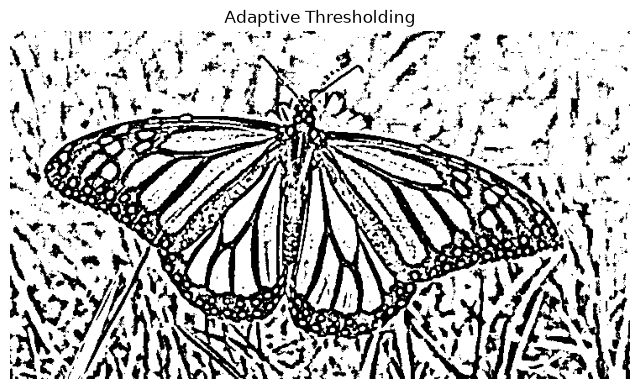

In [20]:
plt.figure(figsize=(8, 6))
plt.imshow(adaptive_threshold, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")
plt.show()

In [21]:
cv2.imwrite(
    "output/06_adaptive_threshold.jpg",
    adaptive_threshold
)

True

In [22]:
binary = otsu_threshold

In [23]:
kernel = np.ones((3, 3), np.uint8)

sure_bg = cv2.dilate(
    binary,
    kernel,
    iterations=3
)

In [24]:
dist_transform = cv2.distanceTransform(
    binary,
    cv2.DIST_L2,
    5
)

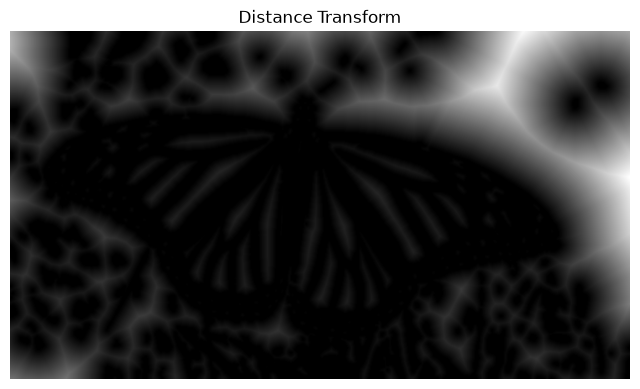

In [25]:
plt.figure(figsize=(8, 6))
plt.imshow(dist_transform, cmap="gray")
plt.title("Distance Transform")
plt.axis("off")
plt.show()

In [26]:
ret, sure_fg = cv2.threshold(
    dist_transform,
    0.5 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

In [27]:
unknown = cv2.subtract(
    sure_bg,
    sure_fg
)

In [28]:
ret, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown == 255] = 0

In [29]:
watershed_image = image.copy()

markers = cv2.watershed(
    watershed_image,
    markers
)

In [30]:
watershed_image[markers == -1] = [0, 0, 255]

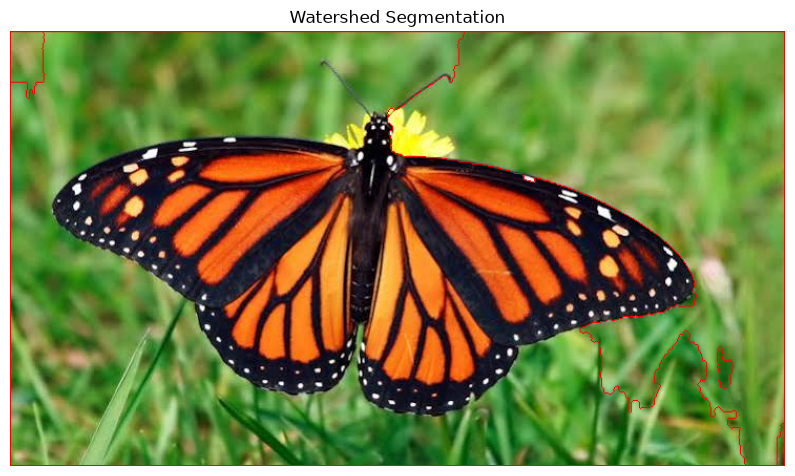

In [31]:
plt.figure(figsize=(10, 7))
plt.imshow(
    cv2.cvtColor(watershed_image, cv2.COLOR_BGR2RGB)
)
plt.title("Watershed Segmentation")
plt.axis("off")
plt.show()

In [32]:
cv2.imwrite(
    "output/07_watershed.jpg",
    watershed_image
)

True

In [33]:
rgb_image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

In [34]:
pixel_values = rgb_image.reshape((-1, 3))

pixel_values = np.float32(pixel_values)

print("Pixel data shape:", pixel_values.shape)

Pixel data shape: (305532, 3)


In [35]:
k = 3

In [36]:
criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    0.2
)

_, labels, centers = cv2.kmeans(
    pixel_values,
    k,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

In [37]:
centers = np.uint8(centers)

segmented_data = centers[labels.flatten()]

segmented_image = segmented_data.reshape(
    rgb_image.shape
)

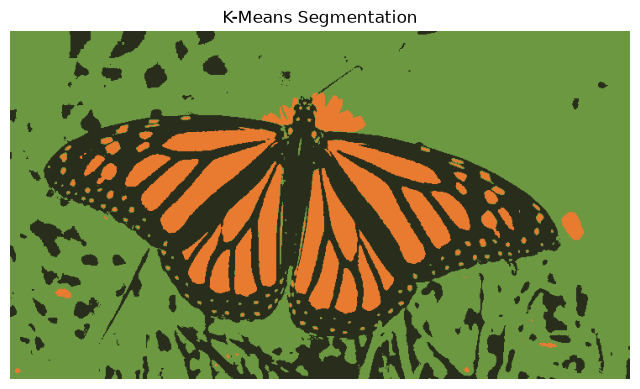

In [38]:
plt.figure(figsize=(8, 6))
plt.imshow(segmented_image)
plt.title("K-Means Segmentation")
plt.axis("off")
plt.show()

In [39]:
cv2.imwrite(
    "output/08_kmeans.jpg",
    cv2.cvtColor(
        segmented_image,
        cv2.COLOR_RGB2BGR
    )
)

True

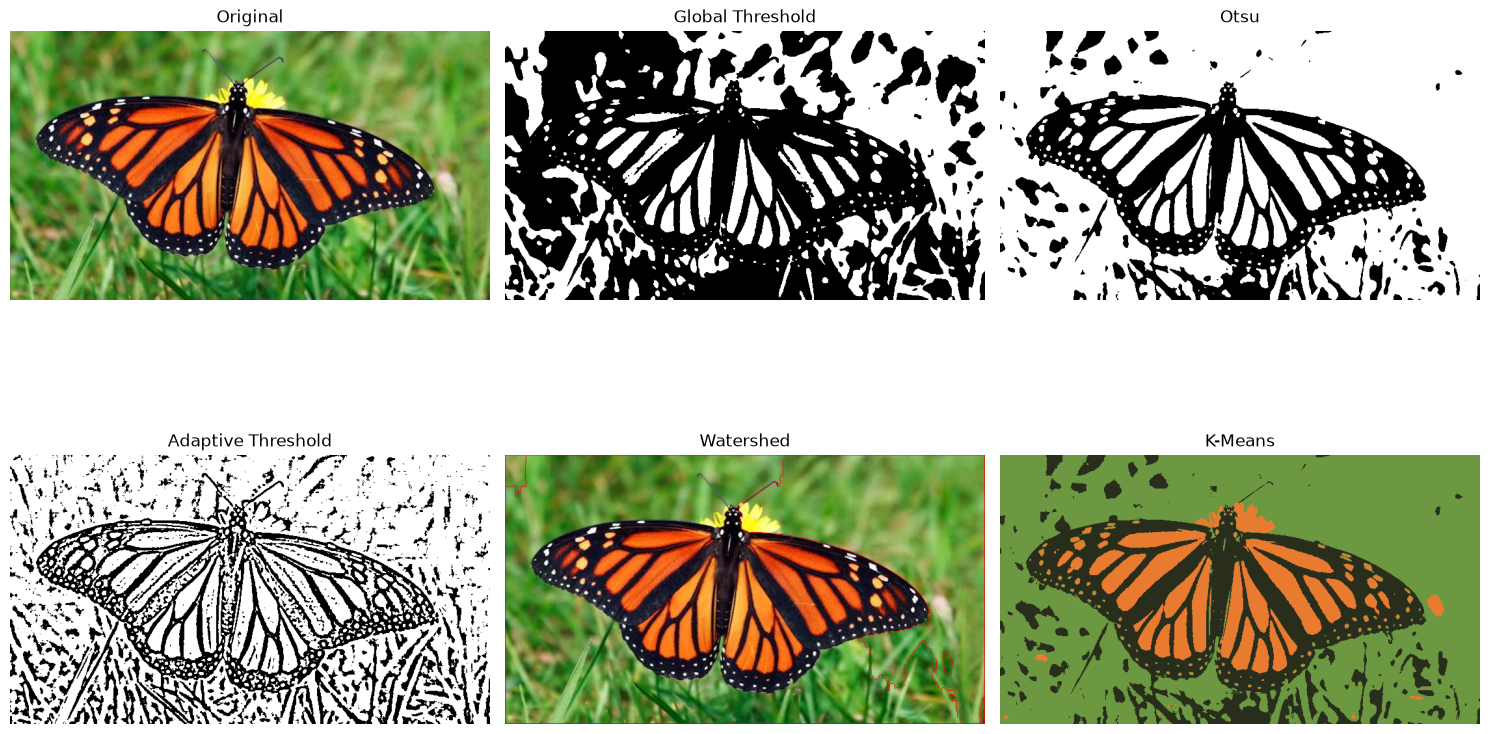

In [40]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(global_threshold, cmap="gray")
plt.title("Global Threshold")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(otsu_threshold, cmap="gray")
plt.title("Otsu")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(adaptive_threshold, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(cv2.cvtColor(watershed_image, cv2.COLOR_BGR2RGB))
plt.title("Watershed")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(segmented_image)
plt.title("K-Means")
plt.axis("off")

plt.tight_layout()
plt.show()